# Signal

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# style of plot
plt.style.use('ggplot')

create one signal

$$
x = A \sin(2\pi f t)
$$

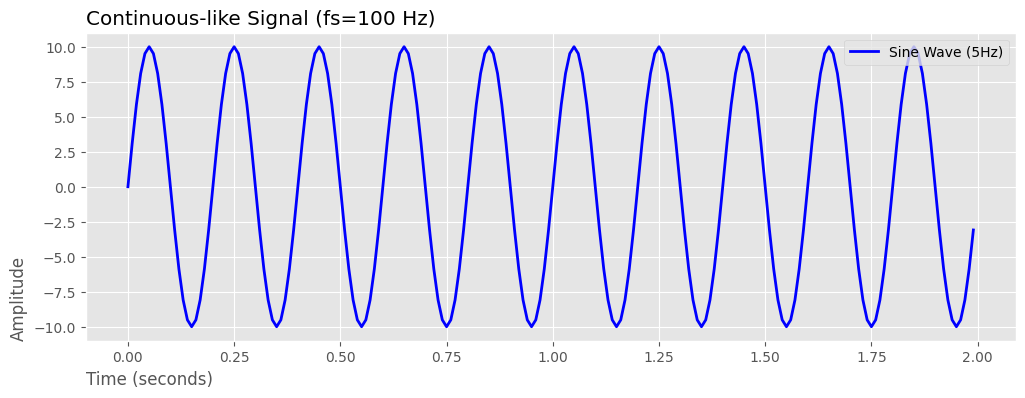

Signal Shape: (200,)
First 10 samples: [ 0.          3.09016994  5.87785252  8.09016994  9.51056516 10.
  9.51056516  8.09016994  5.87785252  3.09016994]


In [3]:
fs = 100 # Sampling rate 100Hz - each 1 second has 100 Samples
duration = 2.0 # long of signal - 2 second
f = 5 # frequency 5Hz
A = 10 # Amplitude


t = np.arange(0, duration, 1/fs) # time
x = A * np.sin(2 * np.pi * f * t) # signal A * sin(2π * f * t)


plt.figure(figsize=(12, 4))
plt.plot(t, x, label='Sine Wave (5Hz)', color='blue', linewidth=2)
plt.title(f'Continuous-like Signal (fs={fs} Hz)', loc="left")
plt.xlabel('Time (seconds)', loc="left")
plt.ylabel('Amplitude', loc="bottom")
plt.grid(True)
plt.legend()
plt.show()

print(f"Signal Shape: {x.shape}")
print(f"First 10 samples: {x[:10]}")

change Sampling rate

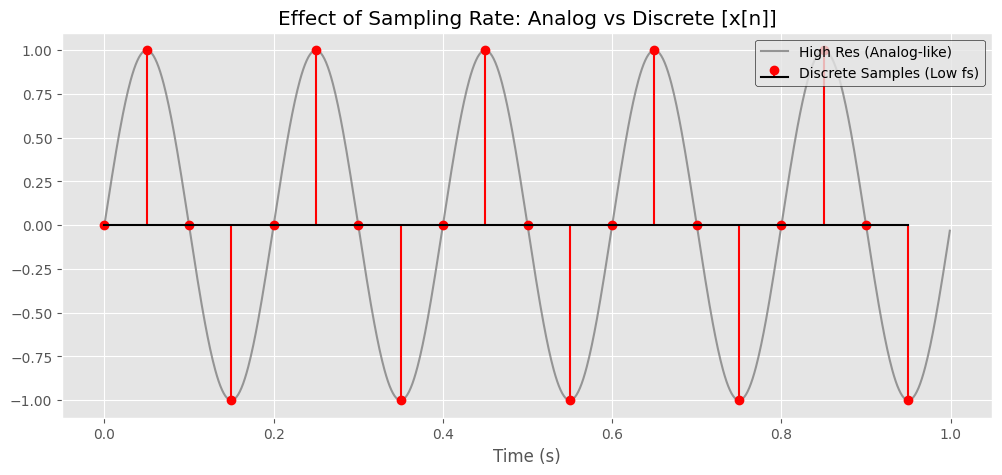

In [4]:
fs_high = 1000  # high quality
fs_low = 20     # low quality

t_high = np.arange(0, 1, 1/fs_high)
t_low = np.arange(0, 1, 1/fs_low)


# signal
x_high = np.sin(2 * np.pi * 5 * t_high)
x_low = np.sin(2 * np.pi * 5 * t_low)


plt.figure(figsize=(12, 5))

plt.plot(t_high, x_high, label='High Res (Analog-like)', color='gray', alpha=0.8)
plt.stem(t_low, x_low, linefmt='r-', markerfmt='ro', basefmt='k', label='Discrete Samples (Low fs)')
plt.title('Effect of Sampling Rate: Analog vs Discrete [x[n]]')
plt.xlabel('Time (s)')
plt.legend(loc="upper right", edgecolor="black")
plt.show()

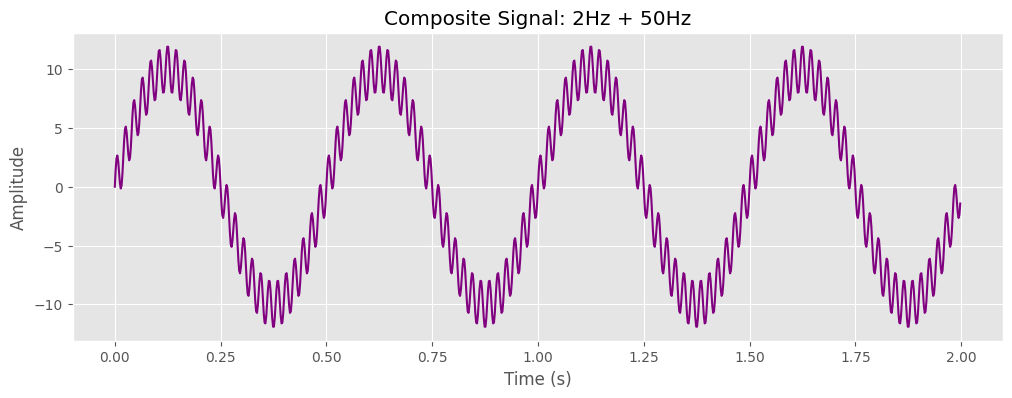

In [5]:
fs = 500
t = np.arange(0, 2, 1/fs)

# سیگنال ۱: فرکانس پایین و دامنه بالا (مثل موج اصلی دریا)
freq1 = 2
amp1 = 10
s1 = amp1 * np.sin(2 * np.pi * freq1 * t)

# سیگنال ۲: فرکانس بالا و دامنه کم (مثل ریزموج‌های روی آب)
freq2 = 50
amp2 = 2
s2 = amp2 * np.sin(2 * np.pi * freq2 * t)

# سیگنال ترکیبی
composite_signal = s1 + s2

plt.figure(figsize=(12, 4))
plt.plot(t, composite_signal, color='purple')
plt.title(f'Composite Signal: {freq1}Hz + {freq2}Hz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

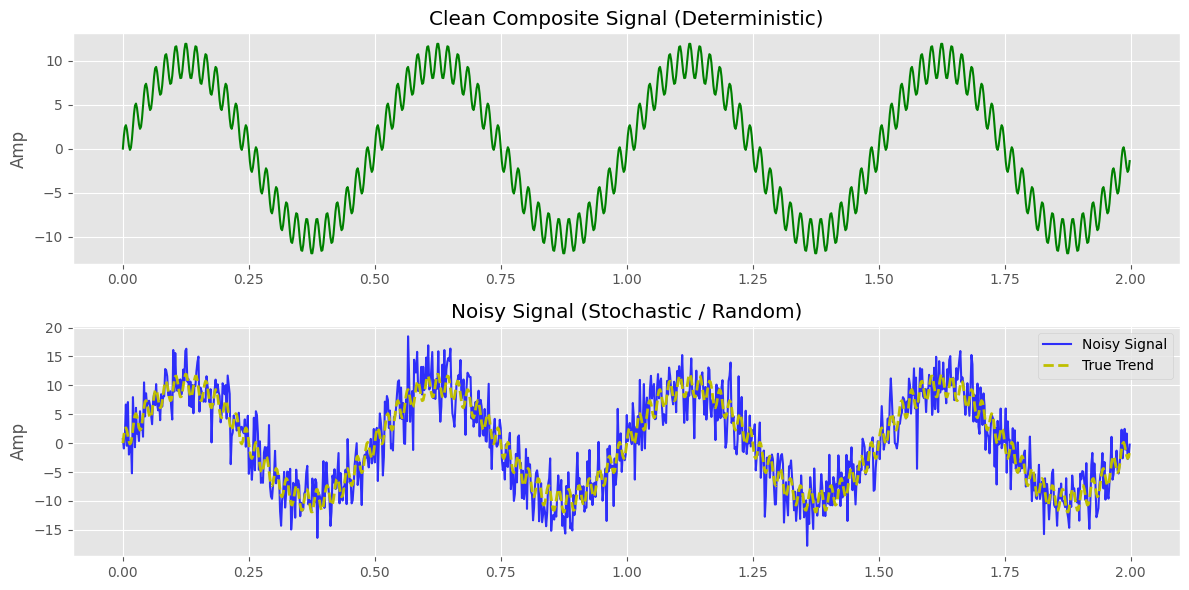

In [6]:
# --- تنظیمات نویز ---
noise_level = 3  # قدرت نویز (انحراف معیار)

# تولید نویز سفید با توزیع نرمال
# میانگین = ۰، انحراف معیار = ۳
noise = np.random.normal(0, noise_level, len(t))

# سیگنال نویزی شده
noisy_signal = composite_signal + noise

# --- رسم نمودار مقایسه‌ای ---
plt.figure(figsize=(12, 6))

# پلات ۱: سیگنال تمیز
plt.subplot(2, 1, 1)
plt.plot(t, composite_signal, 'g')
plt.title('Clean Composite Signal (Deterministic)')
plt.ylabel('Amp')

# پلات ۲: سیگنال نویزی
plt.subplot(2, 1, 2)
plt.plot(t, noisy_signal, 'b', alpha=0.8, label='Noisy Signal')
plt.plot(t, composite_signal, 'y--', linewidth=2, label='True Trend') # روند اصلی
plt.title('Noisy Signal (Stochastic / Random)')
plt.ylabel('Amp')
plt.legend()

plt.tight_layout()
plt.show()

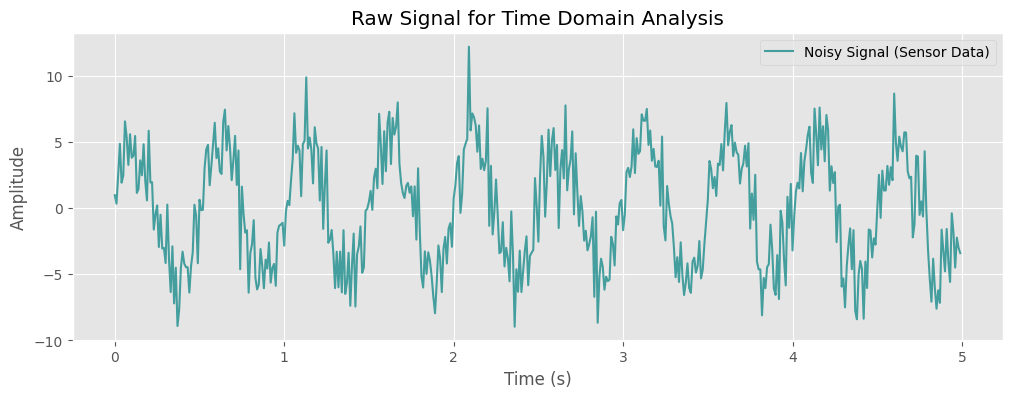

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# تنظیمات اولیه
plt.style.use('ggplot')

# ۱. تولید سیگنال مصنوعی (همانند جلسه قبل)
fs = 100            # فرکانس نمونه‌برداری
duration = 5.0      # ۵ ثانیه
t = np.arange(0, duration, 1/fs)

# سیگنال اصلی (تمیز)
freq = 2  # ۲ هرتز
signal_clean = 5 * np.sin(2 * np.pi * freq * t)

# اضافه کردن نویز (تصادفی)
np.random.seed(42) # برای اینکه نتایج همه دانشجویان یکسان باشد
noise = np.random.normal(0, 2, len(t)) # میانگین ۰ و انحراف ۲
signal_noisy = signal_clean + noise

# نمایش سیگنال
plt.figure(figsize=(12, 4))
plt.plot(t, signal_noisy, label='Noisy Signal (Sensor Data)', color='teal', alpha=0.7)
plt.title('Raw Signal for Time Domain Analysis')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

--- Statistical Features ---
Mean (DC Offset): 0.0137
Variance (Activity Level): 17.6341
Max Peak: 12.2296
Peak-to-Peak Range: 21.1913


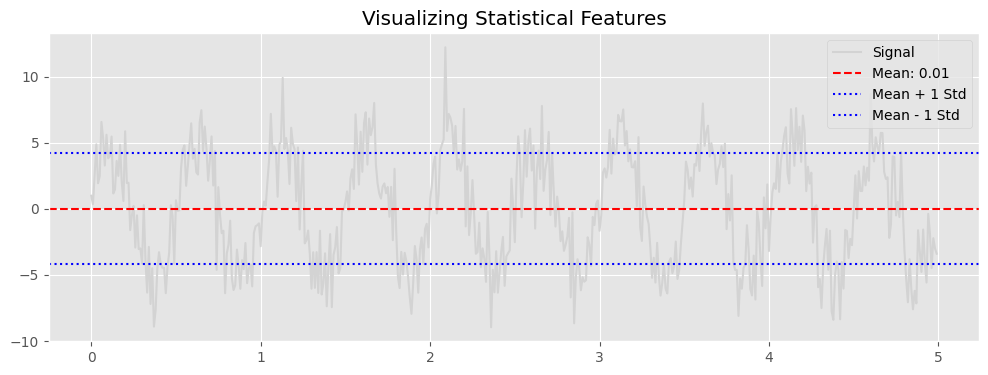

In [8]:
# --- محاسبه ویژگی‌های آماری ---

# ۱. میانگین (Mean) 
# فرمول: (1/N) * sum(x)
mean_val = np.mean(signal_noisy)

# ۲. واریانس و انحراف معیار (Variance & Std) 
# فرمول: (1/N) * sum((x - mean)^2)
variance_val = np.var(signal_noisy)
std_val = np.std(signal_noisy)

# ۳. مقادیر اکسترمم (Min/Max & Peak) 
max_val = np.max(signal_noisy)
min_val = np.min(signal_noisy)

# دامنه پیک-تا-پیک (Peak-to-Peak)
# فرمول: Max - Min
ptp_val = np.ptp(signal_noisy) # یا max_val - min_val

print(f"--- Statistical Features ---")
print(f"Mean (DC Offset): {mean_val:.4f}")
print(f"Variance (Activity Level): {variance_val:.4f}")
print(f"Max Peak: {max_val:.4f}")
print(f"Peak-to-Peak Range: {ptp_val:.4f}")

# --- نمایش روی نمودار (برای درک شهودی) ---
plt.figure(figsize=(12, 4))
plt.plot(t, signal_noisy, color='lightgray', label='Signal')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axhline(mean_val + std_val, color='blue', linestyle=':', label='Mean + 1 Std')
plt.axhline(mean_val - std_val, color='blue', linestyle=':', label='Mean - 1 Std')
plt.legend()
plt.title('Visualizing Statistical Features')
plt.show()

power and energy

In [9]:
# --- ویژگی‌های مبتنی بر انرژی ---

# ۱. انرژی سیگنال (Signal Energy) 
# فرمول: sum(x[n]^2)
energy = np.sum(signal_noisy ** 2)

# ۲. توان سیگنال (Signal Power) 
# فرمول: (1/N) * sum(x[n]^2)  یا همان میانگین مربع‌ها
power = np.mean(signal_noisy ** 2)

# ۳. مقدار موثر (RMS - Root Mean Square) 
# فرمول: sqrt(Power)
rms = np.sqrt(power)

print(f"--- Energy & Power Features ---")
print(f"Energy: {energy:.4f} (Dependent on signal length)")
print(f"Power:  {power:.4f} (Independent of length)")
print(f"RMS:    {rms:.4f} (Effective Amplitude)")



--- Energy & Power Features ---
Energy: 8817.1360 (Dependent on signal length)
Power:  17.6343 (Independent of length)
RMS:    4.1993 (Effective Amplitude)


In [16]:
np.diff(np.signbit(signal_noisy))

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False,  True,  True, False,
       False, False, False,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True, False,  True,  True, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True, False,  True,
       False, False,

In [14]:
np.where(np.diff(np.signbit(signal_noisy)))[0]

array([ 22,  24,  25,  30,  31,  46,  47,  49,  50,  52,  73,  74,  75,
       101, 122, 123, 125, 149, 151, 152, 175, 176, 177, 178, 179, 199,
       203, 204, 220, 221, 222, 224, 225, 247, 249, 250, 253, 254, 261,
       262, 270, 271, 273, 274, 275, 297, 299, 301, 323, 325, 327, 349,
       374, 375, 376, 377, 378, 396, 397, 398, 399, 401, 425, 426, 428,
       450, 451, 452, 470, 472, 474, 475, 476, 477, 478])

--- Temporal Pattern Features ---
Total Zero Crossings: 75
Zero Crossing Rate (Hz): 15.00


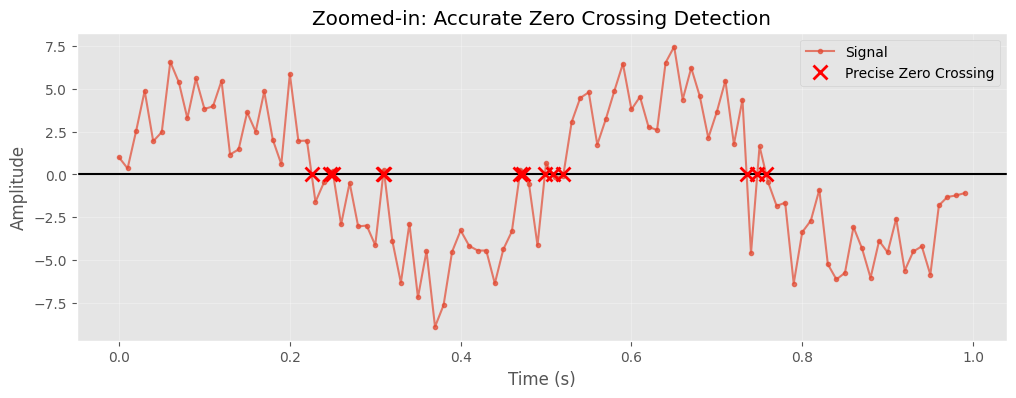

In [17]:
# --- نرخ عبور از صفر (ZCR) ---

# روش برداری و دقیق (Vectorized)
# ۱. استفاده از signbit برای سرعت و دقت بالاتر در تشخیص تغییر علامت
# ۲. np.diff تغییرات را پیدا می‌کند (True یعنی علامت تغییر کرده)
zcr_indices = np.where(np.diff(np.signbit(signal_noisy)))[0]
zcr_count = len(zcr_indices)

# محاسبه نرخ (Rate)
zcr_rate = zcr_count / duration  # تعداد عبور در ثانیه (Hz)

print(f"--- Temporal Pattern Features ---")
print(f"Total Zero Crossings: {zcr_count}")
print(f"Zero Crossing Rate (Hz): {zcr_rate:.2f}")

# --- نمایش دقیق نقاط عبور از صفر (با اصلاح بصری) ---
plt.figure(figsize=(12, 4))

# زوم کردن روی ۱۰۰ نمونه اول برای وضوح بیشتر
zoom_range = 100
plt.plot(t[:zoom_range], signal_noisy[:zoom_range], label='Signal', marker='.', alpha=0.7)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') # خط مبنای صفر

# فیلتر کردن ایندکس‌های تقاطع که در بازه زوم هستند
zoom_indices = zcr_indices[zcr_indices < zoom_range - 1]

# محاسبه محل دقیق زمانی که سیگنال صفر می‌شود (درونیابی خطی)
# فرمول: t_zero = t1 - y1 * (dt / dy)
t_crossings = []
for i in zoom_indices:
    t1, t2 = t[i], t[i+1]
    y1, y2 = signal_noisy[i], signal_noisy[i+1]
    # پیدا کردن زمان دقیق صفر شدن بین دو نقطه
    t_zero = t1 - y1 * ((t2 - t1) / (y2 - y1))
    t_crossings.append(t_zero)

# رسم ضربدرها دقیقاً روی خط صفر (y=0)
plt.plot(t_crossings, np.zeros_like(t_crossings), 'rx', 
         markersize=10, markeredgewidth=2, label='Precise Zero Crossing', zorder=5)

plt.title('Zoomed-in: Accurate Zero Crossing Detection')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

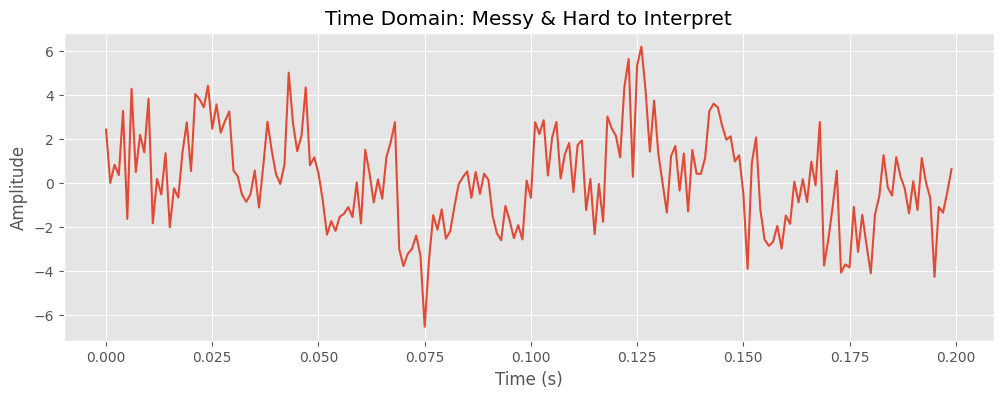

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# تنظیمات اولیه
plt.style.use('ggplot')

# ۱. تنظیمات سیگنال
fs = 1000           # فرکانس نمونه‌برداری (Hz) - اسلاید ۱۹
duration = 2.0      # طول سیگنال (ثانیه)
N = int(fs * duration) # تعداد کل نمونه‌ها
t = np.arange(0, duration, 1/fs)

# ۲. ساخت سیگنال ترکیبی (Composite Signal)
# موج ۱: فرکانس پایین (۱۰ هرتز) - مثلا ریتم آلفا مغز
f1, a1 = 10, 2
s1 = a1 * np.sin(2 * np.pi * f1 * t)

# موج ۲: فرکانس متوسط (۵۰ هرتز) - مثلا نویز برق شهر
f2, a2 = 50, 1.5
s2 = a2 * np.sin(2 * np.pi * f2 * t)

# موج ۳: فرکانس بالا (۱۲۰ هرتز) - مثلا نویز فرکانس بالا
f3, a3 = 120, 0.5
s3 = a3 * np.sin(2 * np.pi * f3 * t)

# ۳. اضافه کردن نویز سفید (White Noise)
np.random.seed(1)
noise = np.random.normal(0, 1.5, N)

# سیگنال نهایی
signal = s1 + s2 + s3 + noise

# نمایش در حوزه زمان (Time Domain) - (تصویر شلوغ)
plt.figure(figsize=(12, 4))
plt.plot(t[:200], signal[:200]) # فقط ۲۰۰ نمونه اول را نشان می‌دهیم
plt.title('Time Domain: Messy & Hard to Interpret')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

FFT

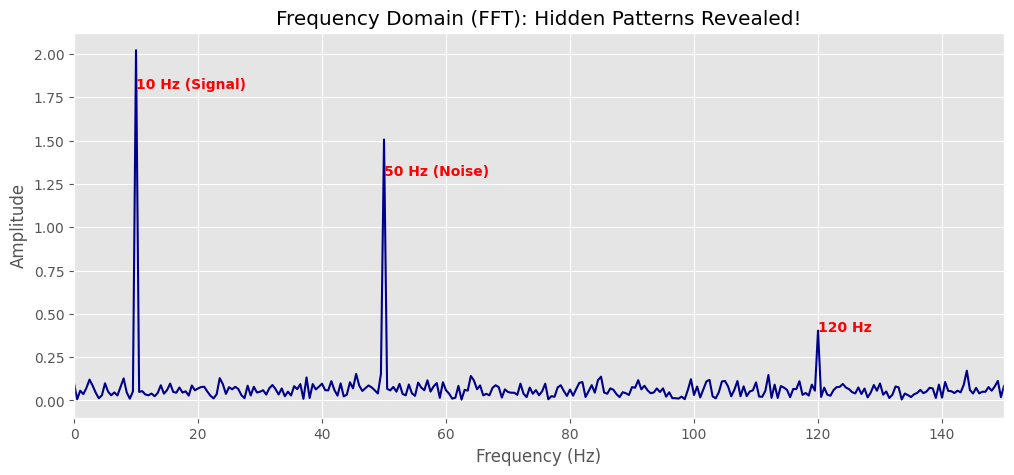

In [ ]:
# --- محاسبات FFT ---

# ۱. محاسبه FFT
fft_values = np.fft.fft(signal)

# N = int(fs * duration) # befor
# ۲. محاسبه محور فرکانس (Frequency Bin Centers)
freqs = np.fft.fftfreq(N, 1/fs)

# ۳. حذف نیمه منفی و نرمال‌سازی (فقط فرکانس‌های مثبت)
# ما فقط نیمه اول آرایه را برمی‌داریم (:N//2)
positive_freqs = freqs[:N//2]
positive_fft = np.abs(fft_values[:N//2]) * (2/N)  # ضرب در 2/N برای نرمال‌سازی دامنه

# --- رسم نمودار دامنه-فرکانس ---
plt.figure(figsize=(12, 5))
plt.plot(positive_freqs, positive_fft, color='darkblue')

# مشخص کردن قله‌های واقعی
plt.title('Frequency Domain (FFT): Hidden Patterns Revealed!')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 150) # زوم روی محدوده مهم (۰ تا ۱۵۰ هرتز)
plt.grid(True)

# اضافه کردن متن راهنما روی نمودار
plt.text(10, 1.8, '10 Hz (Signal)', color='red', fontweight='bold')
plt.text(50, 1.3, '50 Hz (Noise)', color='red', fontweight='bold')
plt.text(120, 0.4, '120 Hz', color='red', fontweight='bold')

plt.show()

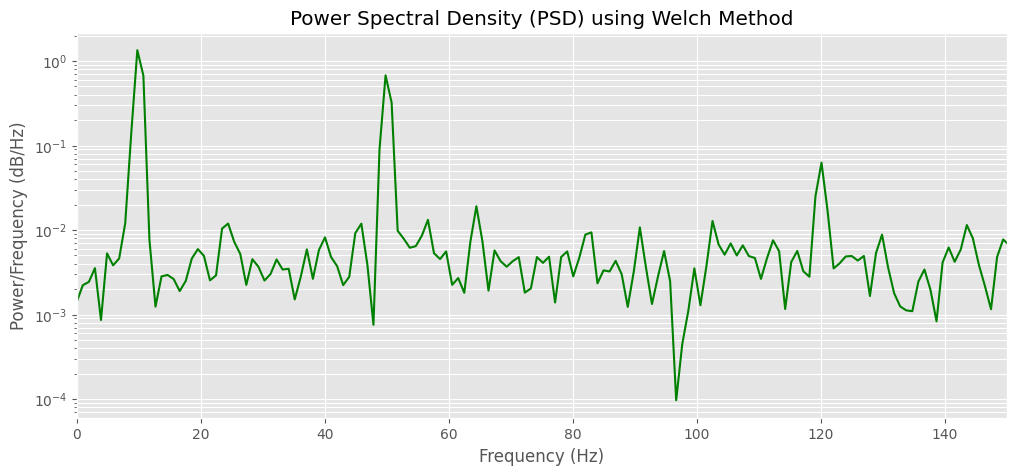

In [21]:
# --- محاسبات PSD (روش Welch) ---
# nperseg: طول هر پنجره برای میانگین‌گیری
f_welch, S_welch = welch(signal, fs, nperseg=1024)

plt.figure(figsize=(12, 5))
plt.semilogy(f_welch, S_welch, color='green') # استفاده از مقیاس لگاریتمی برای محور Y
plt.title('Power Spectral Density (PSD) using Welch Method')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.xlim(0, 150)
plt.grid(True, which="both")
plt.show()

--- Extracted Frequency Features (Input for ML Model) ---
Delta (1-4 Hz): 0.0051
Theta (4-8 Hz): 0.0167
Alpha (8-13 Hz): 2.0470
Beta (13-30 Hz): 0.0739
Gamma (30+ Hz): 1.3761


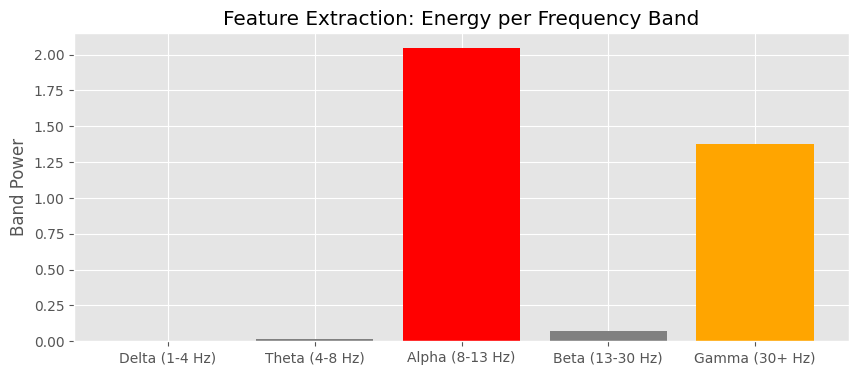

In [23]:
# --- Feature Extraction: Band Power ---
# فرض کنید می‌خواهیم انرژی را در باندهای فرکانسی خاص استخراج کنیم

bands = {
    "Delta (1-4 Hz)": (1, 4),
    "Theta (4-8 Hz)": (4, 8),
    "Alpha (8-13 Hz)": (8, 13), # باید انرژی بالایی داشته باشد چون ۱۰ هرتز داریم
    "Beta (13-30 Hz)": (13, 30),
    "Gamma (30+ Hz)": (30, 100) # شامل ۵۰ هرتز ما می‌شود
}

print("--- Extracted Frequency Features (Input for ML Model) ---")

features = {}
for band_name, (low, high) in bands.items():
    # پیدا کردن ایندکس‌های مربوط به بازه فرکانسی
    idx = np.logical_and(f_welch >= low, f_welch <= high)
    
    # محاسبه انرژی باند (انتگرال زیر نمودار PSD)
    # از Simpson's rule یا trapz استفاده می‌کنیم، اما جمع ساده هم برای دمو کافیست
    band_power = np.trapezoid(S_welch[idx], f_welch[idx])
    features[band_name] = band_power
    
    print(f"{band_name}: {band_power:.4f}")

# نمایش گرافیکی ویژگی‌ها
plt.figure(figsize=(10, 4))
plt.bar(features.keys(), features.values(), color=['gray', 'gray', 'red', 'gray', 'orange'])
plt.title('Feature Extraction: Energy per Frequency Band')
plt.ylabel('Band Power')
plt.show()

Preprocessing

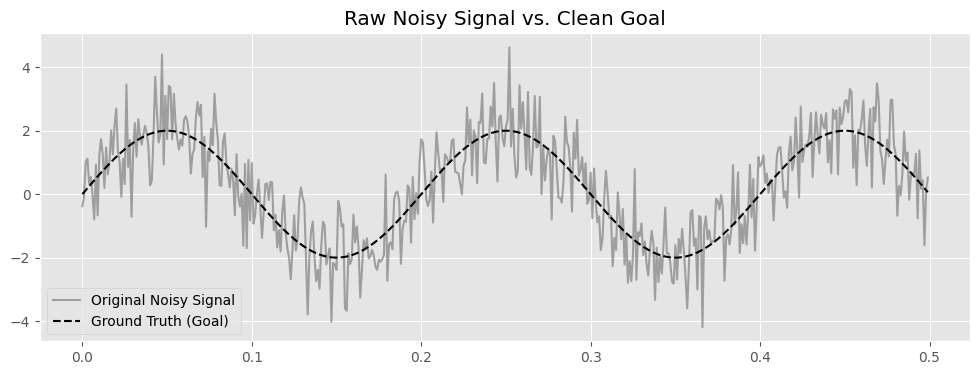

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# تنظیمات اولیه
plt.style.use('ggplot')

# ۱. تولید سیگنال نویزی (همانند بخش قبل)
fs = 1000
duration = 2.0
t = np.arange(0, duration, 1/fs)

# سیگنال اصلی (Low Frequency Trend)
s_clean = 2 * np.sin(2 * np.pi * 5 * t) # ۵ هرتز (سیگنال مفید)

# نویز فرکانس بالا (High Frequency Noise)
noise_high = 0.5 * np.sin(2 * np.pi * 120 * t) # ۱۲۰ هرتز

# نویز سفید (White Noise)
noise_white = np.random.normal(0, 0.8, len(t))

# سیگنال نهایی
signal_noisy = s_clean + noise_high + noise_white

# نمایش
plt.figure(figsize=(12, 4))
plt.plot(t[:500], signal_noisy[:500], label='Original Noisy Signal', color='gray', alpha=0.7)
plt.plot(t[:500], s_clean[:500], label='Ground Truth (Goal)', color='black', linestyle='--')
plt.title('Raw Noisy Signal vs. Clean Goal')
plt.legend()
plt.show()

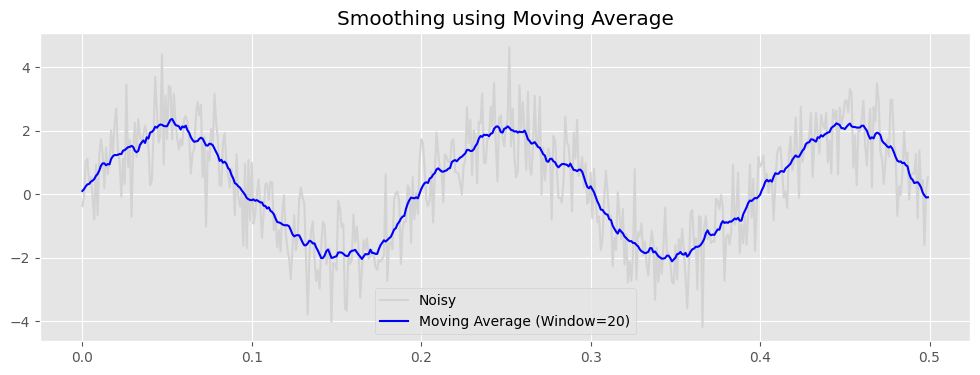

In [2]:
# --- روش ۱: میانگین متحرک (Moving Average) ---

def moving_average(signal, window_size):
    # استفاده از کانولوشن برای محاسبه سریع میانگین
    window = np.ones(window_size) / window_size
    return np.convolve(signal, window, mode='same')

# اعمال فیلتر با پنجره ۲۰ تایی
ma_filtered = moving_average(signal_noisy, window_size=20)

plt.figure(figsize=(12, 4))
plt.plot(t[:500], signal_noisy[:500], label='Noisy', color='lightgray')
plt.plot(t[:500], ma_filtered[:500], label='Moving Average (Window=20)', color='blue')
plt.title('Smoothing using Moving Average')
plt.legend()
plt.show()

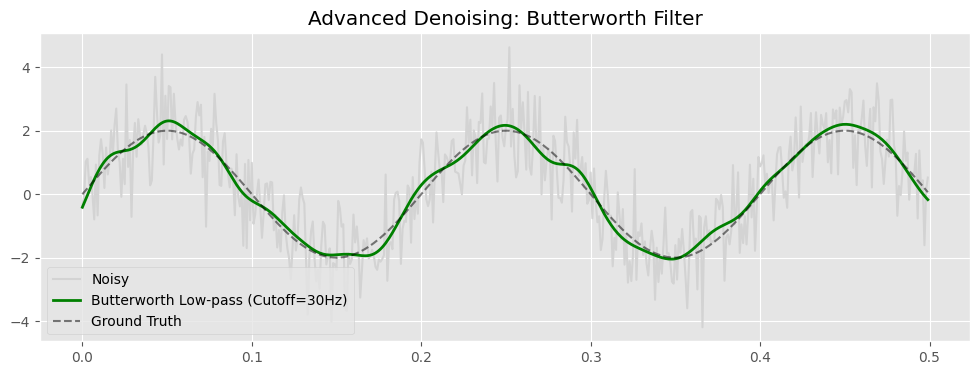

In [3]:
# --- روش ۲: فیلتر پایین‌گذر باترورث (Butterworth Low-pass) ---

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs  # حد نایکوئیست (نصف نرخ نمونه‌برداری)
    normal_cutoff = cutoff / nyquist
    # طراحی ضرایب فیلتر
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # اعمال فیلتر بدون تاخیر فاز
    y = filtfilt(b, a, data)
    return y

# اعمال فیلتر (حذف فرکانس‌های بالای ۳۰ هرتز)
# سیگنال ما ۵ هرتز است، نویز ۱۲۰ هرتز -> کات‌آف ۳۰ مناسب است
cutoff_freq = 30
bw_filtered = butter_lowpass_filter(signal_noisy, cutoff_freq, fs)

plt.figure(figsize=(12, 4))
plt.plot(t[:500], signal_noisy[:500], label='Noisy', color='lightgray')
plt.plot(t[:500], bw_filtered[:500], label=f'Butterworth Low-pass (Cutoff={cutoff_freq}Hz)', color='green', linewidth=2)
plt.plot(t[:500], s_clean[:500], label='Ground Truth', color='black', linestyle='--', alpha=0.5)
plt.title('Advanced Denoising: Butterworth Filter')
plt.legend()
plt.show()